In [46]:
!pip install sentence-transformers seaborn matplotlib scikit-learn

In [47]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [48]:
sentences = [

    #cricket
    "The batsman scored a century in the final match.",
    "the bowler delivered a faster yorker to dismiss the batter.",
    "The cricket team celebrated after winning the world cup.",

    #Cooking
    "I added fresh herbs to enhance the taste of the pasta.",
    "Baking a choclate cake requires precise measurements.",
    "The chef sauteed the vegetables in olive oil.",

    #Cybersecurity
    "A strong password helps protect online accounts from hackers.",
    "Cybersecurity experts monitor networks for suspicious activity.",
    "Encryption securies senstive data during transmission.",
    "Phising emails attempt to steal personal information."
]


In [49]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)
print("Embedding Shape", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding Shape (10, 384)


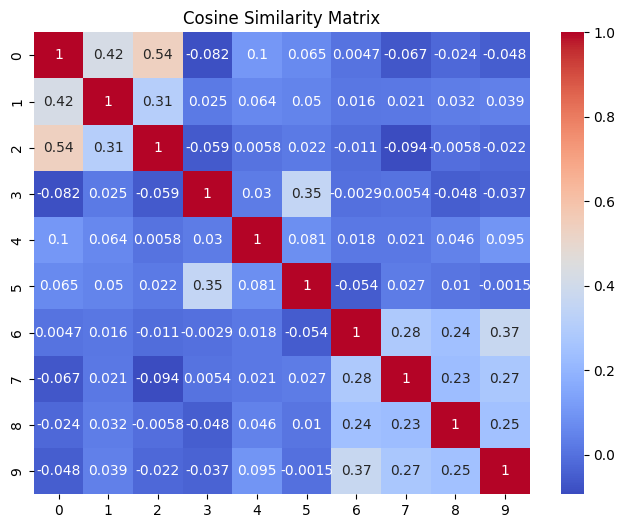

In [50]:
similarity_matrix = cosine_similarity(embeddings)
df = pd.DataFrame(similarity_matrix)
plt.figure(figsize=(8,6))
sns.heatmap(df, annot=True, cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()

In [51]:
query = "The bowler took three wickets in one over."

In [52]:
query_embedding = model.encode([query])
similarities = cosine_similarity(query_embedding, embeddings)[0]
results = list(zip(sentences, similarities))
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)
print("Top 2 most similar sentences:\n")

for sentence, score in results_sorted[:2]:
     print(sentence)
     print("Similarity Score:", score)
     print()

Top 2 most similar sentences:

The batsman scored a century in the final match.
Similarity Score: 0.5843855

the bowler delivered a faster yorker to dismiss the batter.
Similarity Score: 0.5607834

